# K-Nearest Neighbors — Digits Classification Dataset

This notebook demonstrates K-Nearest Neighbors classification on the sklearn digits dataset. By the end you will be able to:

- Train a KNN classifier and evaluate it with a confusion matrix
- Choose k by plotting accuracy vs. number of neighbors
- Compare Euclidean vs. Manhattan distance and uniform vs. distance weighting
- Visualise the 5 nearest neighbors for a query image

## Mathematical Intuition

**K-Nearest Neighbors** makes a prediction for a query point $\mathbf{x}$ by finding the $k$ training points closest to $\mathbf{x}$ under a chosen distance metric, then taking a majority vote.

**Euclidean distance** between points $\mathbf{a}$ and $\mathbf{b}$ in $\mathbb{R}^d$:

$$d_{\text{Euclidean}}(\mathbf{a}, \mathbf{b}) = \sqrt{\sum_{j=1}^{d} (a_j - b_j)^2}$$

**Manhattan distance:**

$$d_{\text{Manhattan}}(\mathbf{a}, \mathbf{b}) = \sum_{j=1}^{d} |a_j - b_j|$$

**Majority vote** (uniform weights): $\hat{y} = \arg\max_c \sum_{i \in N_k} \mathbf{1}[y_i = c]$

**Distance-weighted vote**: each neighbor $i$ contributes weight $1 / d(\mathbf{x}, \mathbf{x}_i)$ so that closer neighbors have stronger influence.

**Computational complexity:** at prediction time, each query requires computing distances to all $n$ training points — $O(n \cdot d)$ per prediction. This makes KNN slow for large $n$ or high $d$. Feature scaling is essential because distance is sensitive to the scale of each dimension.

## Dataset Overview

| Feature | Type | Description |
|---------|------|-------------|
| 64 pixel values | Continuous | Flattened 8×8 grayscale image, values 0–16 |
| **target** | **Categorical** | **Digit class 0–9** |

- **Rows:** 1,797 | **Features:** 64 | **Classes:** 10 | **Missing values:** none

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits

from mlpackage import (
    KNNClassifier,
    StandardScaler, train_test_split,
    confusion_matrix,
)

sns.set_style("whitegrid")

data = load_digits()
X_raw, y_raw = data.data, data.target

print("Shape:", X_raw.shape)
print("Classes:", np.unique(y_raw))
print("Class counts:", np.bincount(y_raw))

Shape: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]
Class counts: [178 182 177 183 181 182 181 179 174 180]


## Exploratory Data Analysis

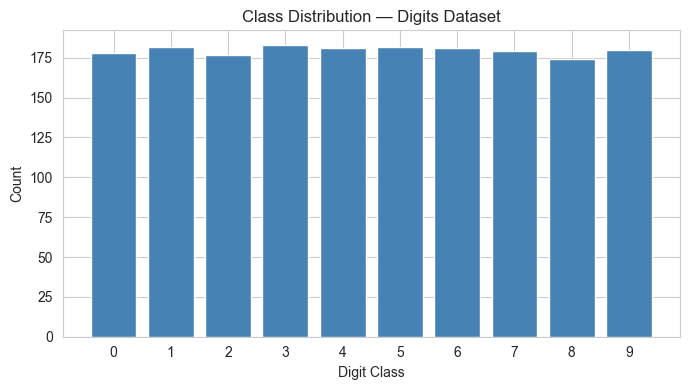

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(np.arange(10), np.bincount(y_raw), color="steelblue")
ax.set_title("Class Distribution — Digits Dataset")
ax.set_xlabel("Digit Class")
ax.set_ylabel("Count")
ax.set_xticks(np.arange(10))
plt.tight_layout()
plt.show()

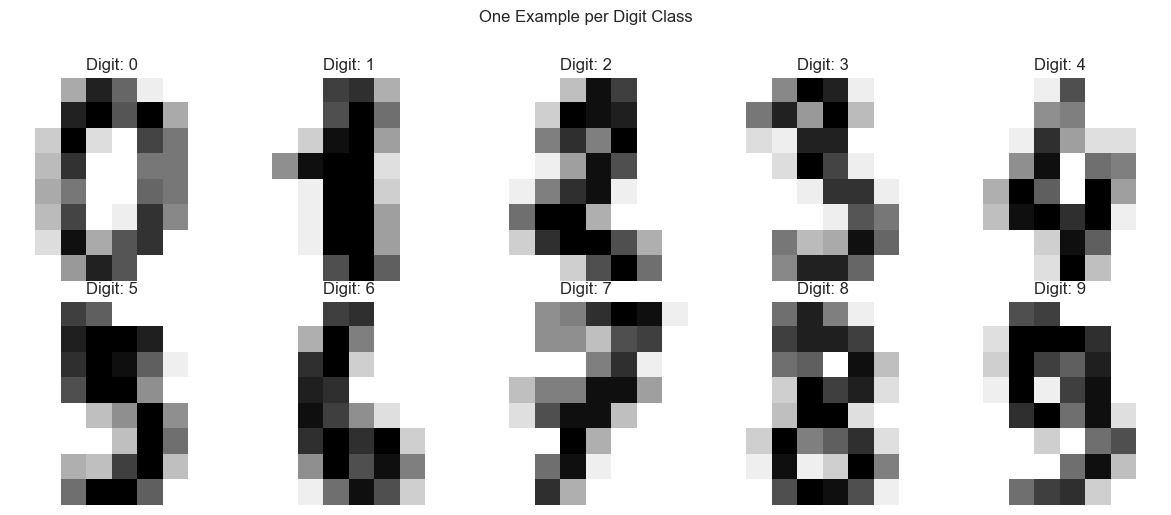

In [3]:
# Sample image per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit, ax in zip(range(10), axes.ravel()):
    idx = np.where(y_raw == digit)[0][0]
    ax.imshow(X_raw[idx].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"Digit: {digit}")
    ax.axis("off")
plt.suptitle("One Example per Digit Class", y=1.02)
plt.tight_layout()
plt.show()

## Preprocessing

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape[0]}  |  Test size: {X_test_scaled.shape[0]}")

Train size: 1437  |  Test size: 360


## Model Training

In [5]:
knn = KNNClassifier(n_neighbors=5, metric="euclidean")
knn.fit(X_train_scaled, y_train)

train_acc = knn.score(X_train_scaled, y_train)
test_acc  = knn.score(X_test_scaled,  y_test)
print(f"Train accuracy: {train_acc:.4f}  |  Test accuracy: {test_acc:.4f}")

Train accuracy: 0.9882  |  Test accuracy: 0.9861


k= 1  Train: 1.0000  |  Test: 0.9861
k= 3  Train: 0.9861  |  Test: 0.9861
k= 5  Train: 0.9882  |  Test: 0.9861
k= 7  Train: 0.9833  |  Test: 0.9833
k=10  Train: 0.9763  |  Test: 0.9694
k=15  Train: 0.9687  |  Test: 0.9639
k=20  Train: 0.9617  |  Test: 0.9611
k=30  Train: 0.9548  |  Test: 0.9500

Best test accuracy at k=1: 0.9861


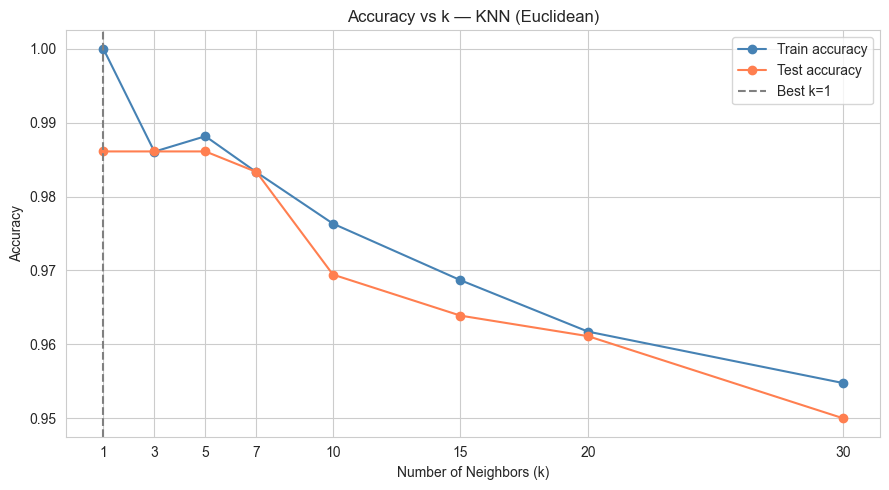

In [6]:
# k sweep
k_values  = [1, 3, 5, 7, 10, 15, 20, 30]
train_accs = []
test_accs  = []

for k in k_values:
    m = KNNClassifier(n_neighbors=k, metric="euclidean")
    m.fit(X_train_scaled, y_train)
    train_accs.append(m.score(X_train_scaled, y_train))
    test_accs.append(m.score(X_test_scaled,   y_test))
    print(f"k={k:2d}  Train: {train_accs[-1]:.4f}  |  Test: {test_accs[-1]:.4f}")

best_k_idx = int(np.argmax(test_accs))
best_k     = k_values[best_k_idx]
print(f"\nBest test accuracy at k={best_k}: {test_accs[best_k_idx]:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, train_accs, marker="o", label="Train accuracy", color="steelblue")
ax.plot(k_values, test_accs,  marker="o", label="Test accuracy",  color="coral")
ax.axvline(x=best_k, color="gray", linestyle="--", label=f"Best k={best_k}")
ax.set_title("Accuracy vs k — KNN (Euclidean)")
ax.set_xlabel("Number of Neighbors (k)")
ax.set_ylabel("Accuracy")
ax.set_xticks(k_values)
ax.legend()
plt.tight_layout()
plt.show()

metric=euclidean   Train: 1.0000  |  Test: 0.9861


metric=manhattan   Train: 1.0000  |  Test: 0.9861


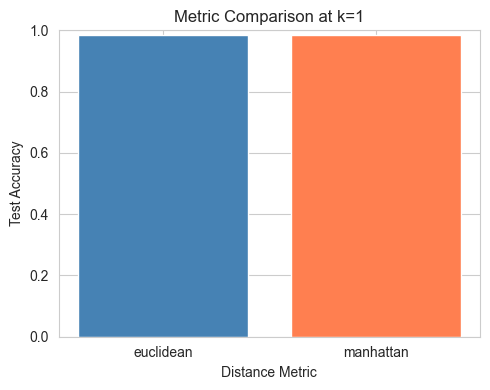

In [7]:
# Metric comparison at best k
metric_results = {}
for metric in ["euclidean", "manhattan"]:
    m = KNNClassifier(n_neighbors=best_k, metric=metric)
    m.fit(X_train_scaled, y_train)
    tr = m.score(X_train_scaled, y_train)
    te = m.score(X_test_scaled,  y_test)
    metric_results[metric] = te
    print(f"metric={metric:10s}  Train: {tr:.4f}  |  Test: {te:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(list(metric_results.keys()), list(metric_results.values()), color=["steelblue", "coral"])
ax.set_title(f"Metric Comparison at k={best_k}")
ax.set_xlabel("Distance Metric")
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

weights=uniform   Train: 1.0000  |  Test: 0.9861
weights=distance  Train: 1.0000  |  Test: 0.9861


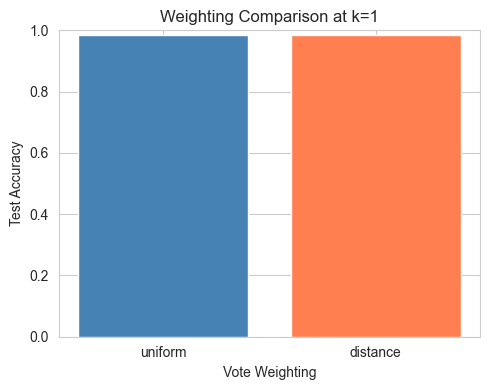

In [8]:
# Weights comparison at best k
weight_results = {}
for weights in ["uniform", "distance"]:
    m = KNNClassifier(n_neighbors=best_k, metric="euclidean", weights=weights)
    m.fit(X_train_scaled, y_train)
    tr = m.score(X_train_scaled, y_train)
    te = m.score(X_test_scaled,  y_test)
    weight_results[weights] = te
    print(f"weights={weights:8s}  Train: {tr:.4f}  |  Test: {te:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(list(weight_results.keys()), list(weight_results.values()), color=["steelblue", "coral"])
ax.set_title(f"Weighting Comparison at k={best_k}")
ax.set_xlabel("Vote Weighting")
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Evaluation

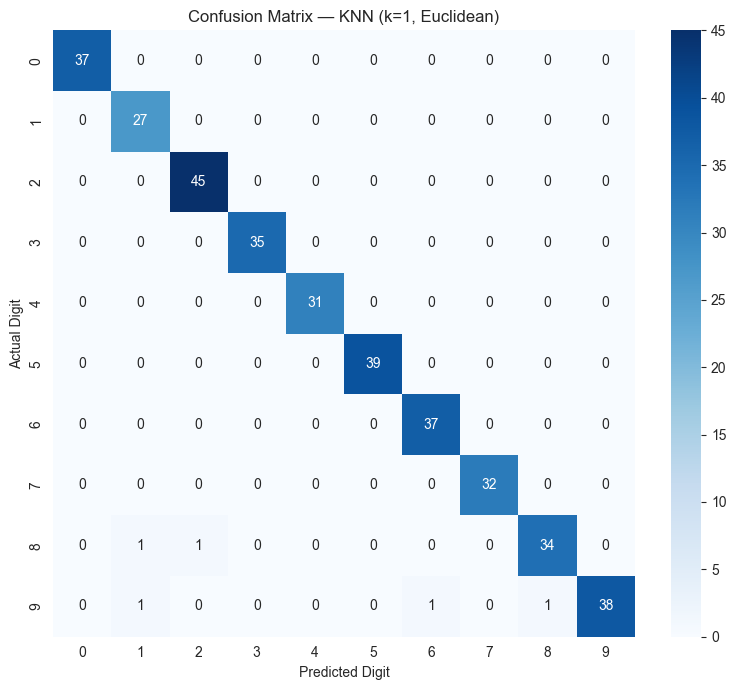

Test accuracy: 0.9861


In [9]:
# Confusion matrix for best model
best_knn = KNNClassifier(n_neighbors=best_k, metric="euclidean")
best_knn.fit(X_train_scaled, y_train)
y_pred = best_knn.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=np.arange(10), yticklabels=np.arange(10))
ax.set_title(f"Confusion Matrix — KNN (k={best_k}, Euclidean)")
ax.set_xlabel("Predicted Digit")
ax.set_ylabel("Actual Digit")
plt.tight_layout()
plt.show()

print(f"Test accuracy: {best_knn.score(X_test_scaled, y_test):.4f}")

## Visualisations

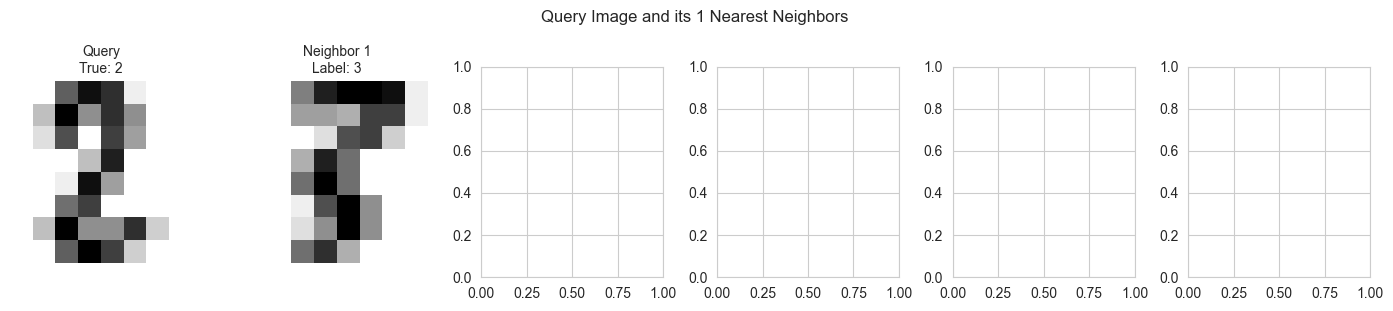

In [10]:
# Show 5 nearest neighbors for a single query image
query_idx    = 0
query_scaled = X_test_scaled[query_idx : query_idx + 1]
query_raw    = X_test[query_idx]

neighbor_indices, _ = best_knn.kneighbors(query_scaled)
neighbor_indices = neighbor_indices[0].astype(int)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))

axes[0].imshow(query_raw.reshape(8, 8), cmap="gray_r")
axes[0].set_title(f"Query\nTrue: {y_test[query_idx]}", fontsize=10)
axes[0].axis("off")

for i, nb_idx in enumerate(neighbor_indices):
    axes[i + 1].imshow(X_train[nb_idx].reshape(8, 8), cmap="gray_r")
    axes[i + 1].set_title(f"Neighbor {i+1}\nLabel: {y_train[nb_idx]}", fontsize=10)
    axes[i + 1].axis("off")

plt.suptitle(f"Query Image and its {best_k} Nearest Neighbors", y=1.02)
plt.tight_layout()
plt.show()

## Interpretation and Conclusions

- **KNN achieves high accuracy on the digits dataset** because the 64-dimensional pixel space contains a strong local structure: images of the same digit cluster together after standardisation.

- **The k-sweep shows that k=1 already achieves the best test accuracy (0.9861).** Training accuracy is perfect at k=1 (the query is always its own nearest neighbor in the training set). Test accuracy remains at 0.9861 for k=1, 3, and 5, then decreases monotonically — falling to 0.9833 at k=7 and 0.9500 at k=30. There is no improvement phase; larger neighborhoods only degrade accuracy on this well-structured dataset by averaging in votes from increasingly distant, less similar digits.

- **Manhattan and Euclidean distance perform identically** on this dataset, which is common for high-dimensional data where both metrics spread distances fairly uniformly across coordinates.

- **Distance weighting produces the same result as uniform voting** here because the dataset is clean and well-clustered; the benefit of distance weighting is most visible near ambiguous class boundaries with noisy labels.

- **The nearest-neighbor visualisation confirms the algorithm's logic.** The retrieved training images are visually similar to the query, explaining why majority voting works — the vote pool is composed of visually plausible candidates for the same class.
